In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [12]:
# 假设读取的数据文件名
file_name = "E:/大数据金融/7ZBS6wYfWt/60384-00大数据金融_彭俞超、戴韡_PPT、代码V2.0/《大数据金融》代码/第4章/案例数据/居民消费聚类案例.csv"  # 文件内容示例：每行包含点的三维坐标，例如: 12,34,56

In [13]:
# 1. 使用 Pandas 读取数据
data = pd.read_csv(file_name, header=None)
points = data.values  # 转换为 NumPy 数组

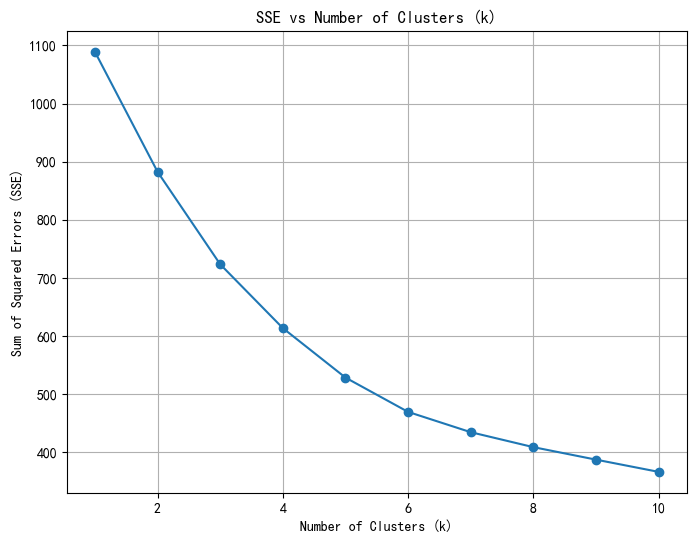

In [14]:
# 2. 碎石图：计算不同 k 的组内误差 (SSE)
sse = []
k_range = range(1, 11)  # 测试 k = 1 到 10
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(points)
    sse.append(kmeans.inertia_)  # SSE: 组内误差

    

# 绘制碎石图
plt.figure(figsize=(8, 6))
plt.plot(k_range, sse, marker='o')
plt.title('SSE vs Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.grid(True)
plt.show()

In [16]:
# 3. 选择 k 聚类 (假设选择 k=3)
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
labels = kmeans.fit_predict(points)

# 输出聚类结果
print("聚类标签:", labels)

聚类标签: [2 2 2 ... 0 1 0]


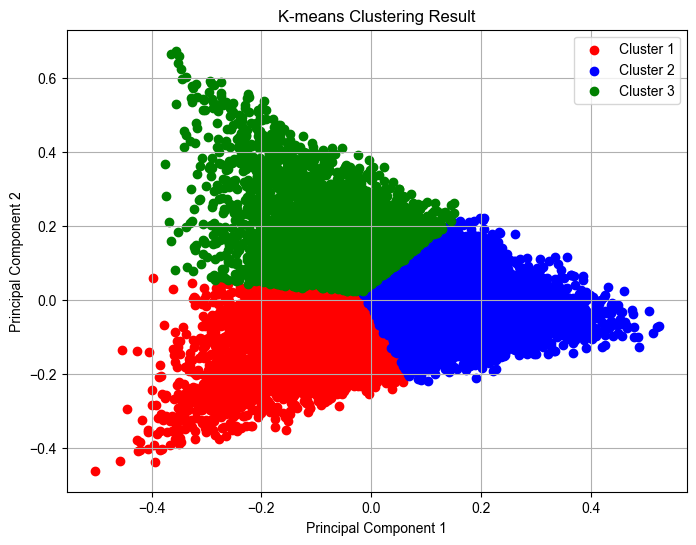

In [25]:
# PCA 降维到二维
pca = PCA(n_components=2)
points_2d = pca.fit_transform(points)

# 绘制聚类结果
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green']  # 定义每个聚类的颜色

for i in range(3):  # 假设有 3 个聚类
    cluster_points = points_2d[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[i], label=f'Cluster {i+1}')

plt.title('K-means Clustering Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# 1

In [57]:
# 假设读取的数据文件名
file_name = "E:/大数据金融/《应用多元统计分析》（第6版）配书资料/《应用多元统计分析》（第6版，王学民编著）配书资料（会不时更新）/《应用多元统计分析》（第6版）文本数据（以逗号为间隔）/examp6.3.3.csv"  # 文件内容示例：每行包含点的三维坐标，例如: 12,34,56

In [58]:
# 1. 使用 Pandas 读取数据
data = pd.read_csv(file_name)
points = data.iloc[:, 1:].values  # 转换为 NumPy 数组

In [59]:
# 使用 StandardScaler 进行标准化
scaler = StandardScaler()
points = scaler.fit_transform(points)

In [50]:
data.head()

,地区,食品,衣着,家庭设备用品及服务,医疗保健,交通和通讯,娱乐教育文化服务,居住,杂项商品和服务
0,北京,2959.19,730.79,749.41,513.34,467.87,1141.82,478.42,457.64
1,天津,2459.77,495.47,697.33,302.87,284.19,735.97,570.84,305.08
2,河北,1495.63,515.90,362.37,285.32,272.95,540.58,364.91,188.63
3,山西,1406.33,477.77,290.15,208.57,201.50,414.72,281.84,212.10
4,内蒙古,1303.97,524.29,254.83,192.17,249.81,463.09,287.87,192.96


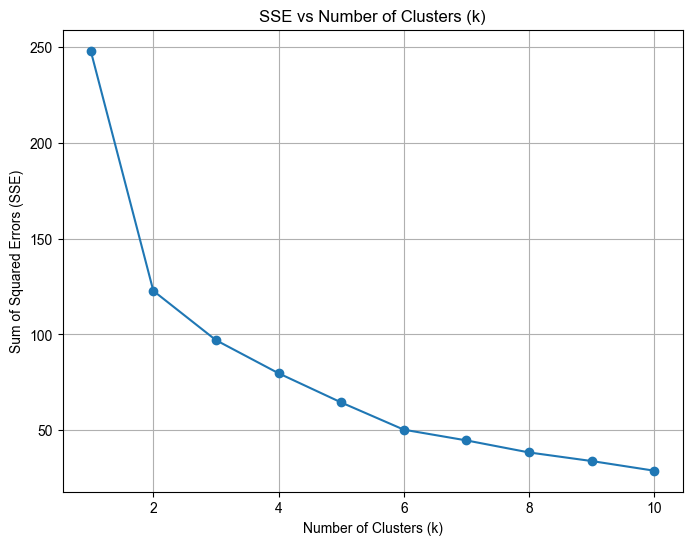

In [60]:
# 2. 碎石图：计算不同 k 的组内误差 (SSE)
sse = []
k_range = range(1, 11)  # 测试 k = 1 到 10
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(points)
    sse.append(kmeans.inertia_)  # SSE: 组内误差

    

# 绘制碎石图
plt.figure(figsize=(8, 6))
plt.plot(k_range, sse, marker='o')
plt.title('SSE vs Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.grid(True)
plt.show()

In [61]:
# 3. 选择 k 聚类 (假设选择 k=3)
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
labels = kmeans.fit_predict(points)

# 输出聚类结果
print("聚类标签:", labels)

聚类标签: [1 2 0 0 0 0 0 0 1 2 1 0 2 0 2 0 2 2 1 2 0 2 2 0 2 2 0 0 0 0 0]


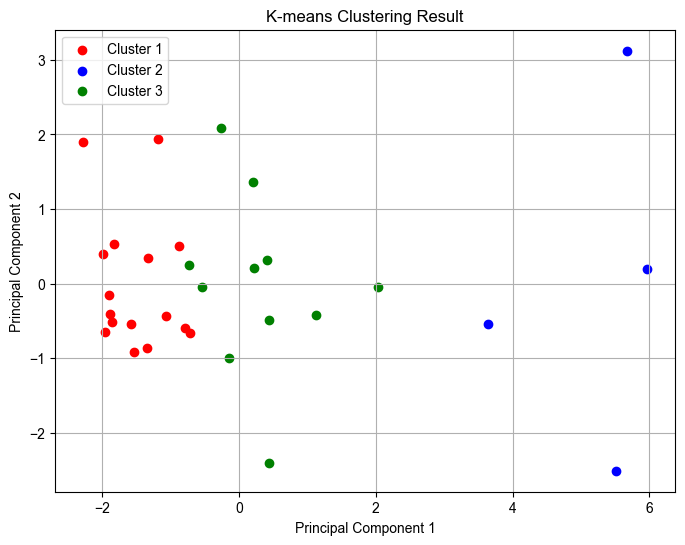

In [62]:
# PCA 降维到二维
pca = PCA(n_components=2)
points_2d = pca.fit_transform(points)

# 绘制聚类结果
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green']  # 定义每个聚类的颜色

for i in range(3):  # 假设有 3 个聚类
    cluster_points = points_2d[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[i], label=f'Cluster {i+1}')

plt.title('K-means Clustering Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

In [54]:
labels 

array([1, 2, 0, 0, 0, 0, 0, 0, 1, 2, 2, 0, 2, 0, 0, 0, 0, 2, 1, 2, 2, 2,
       2, 0, 2, 2, 0, 0, 0, 0, 0])

In [63]:
data['label'] = labels
data

,地区,食品,衣着,家庭设备用品及服务,医疗保健,交通和通讯,娱乐教育文化服务,居住,杂项商品和服务,label
0,北京,2959.19,730.79,749.41,513.34,467.87,1141.82,478.42,457.64,1
1,天津,2459.77,495.47,697.33,302.87,284.19,735.97,570.84,305.08,2
2,河北,1495.63,515.90,362.37,285.32,272.95,540.58,364.91,188.63,0
3,山西,1406.33,477.77,290.15,208.57,201.50,414.72,281.84,212.10,0
4,内蒙古,1303.97,524.29,254.83,192.17,249.81,463.09,287.87,192.96,0
5,辽宁,1730.84,553.90,246.91,279.81,239.18,445.20,330.24,163.86,0
6,吉林,1561.86,492.42,200.49,218.36,220.69,459.62,360.48,147.76,0
7,黑龙江,1410.11,510.71,211.88,277.11,224.65,376.82,317.61,152.85,0
8,上海,3712.31,550.74,893.37,346.93,527.00,1034.98,720.33,462.03,1
9,江苏,2207.58,449.37,572.40,211.92,302.09,585.23,429.77,252.54,2


In [ ]:
#https://www.icourse163.org/learn/CUFE-1003437002?tid=1473153478#/learn/content?type=detail&id=1259935357&cid=1295655918 

In [64]:
# 1. 使用 Pandas 读取数据
data = pd.read_csv('啤酒数据.csv')
points = data.iloc[:, 1:].values  # 转换为 NumPy 数组

In [65]:
data.head()

,啤酒名,热量,钠含量,酒精,价格
0,Budweiser,144,19,4.7,0.43
1,Schlitz,181,19,4.9,0.43
2,Ionenbrau,157,15,4.9,0.48
3,Kronensourc,170,7,5.2,0.73
4,Heineken,152,11,5.0,0.77


In [67]:
points 

array([[144.  ,  19.  ,   4.7 ,   0.43],
       [181.  ,  19.  ,   4.9 ,   0.43],
       [157.  ,  15.  ,   4.9 ,   0.48],
       [170.  ,   7.  ,   5.2 ,   0.73],
       [152.  ,  11.  ,   5.  ,   0.77],
       [145.  ,  23.  ,   4.6 ,   0.26],
       [175.  ,  24.  ,   5.5 ,   0.4 ],
       [149.  ,  27.  ,   4.7 ,   0.42],
       [ 99.  ,  10.  ,   4.3 ,   0.43],
       [113.  ,   6.  ,   3.7 ,   0.44],
       [140.  ,  16.  ,   4.6 ,   0.44],
       [102.  ,  15.  ,   4.1 ,   0.46],
       [135.  ,  11.  ,   4.2 ,   0.5 ],
       [150.  ,  19.  ,   4.7 ,   0.76],
       [149.  ,   6.  ,   5.  ,   0.79],
       [ 68.  ,  15.  ,   2.3 ,   0.36],
       [136.  ,  19.  ,   4.4 ,   0.43],
       [144.  ,  24.  ,   4.9 ,   0.43],
       [ 72.  ,   6.  ,   2.9 ,   0.46],
       [ 97.  ,   7.  ,   4.2 ,   0.47]])

In [68]:
# 使用 StandardScaler 进行标准化
scaler = StandardScaler()
points = scaler.fit_transform(points)

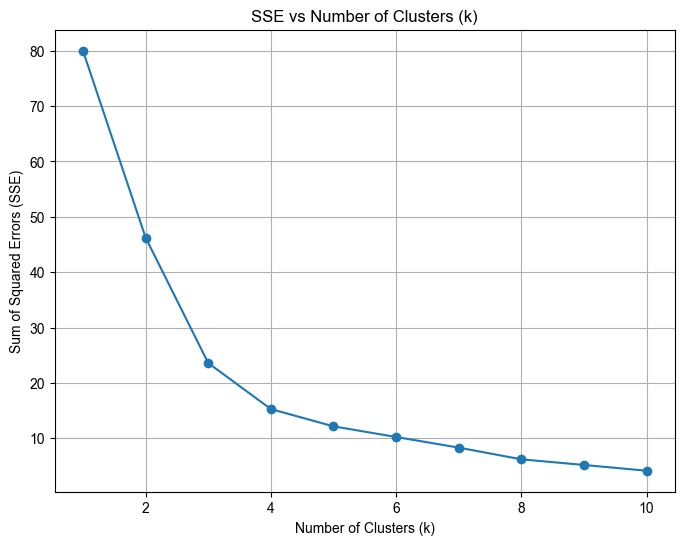

In [69]:
# 2. 碎石图：计算不同 k 的组内误差 (SSE)
sse = []
k_range = range(1, 11)  # 测试 k = 1 到 10
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(points)
    sse.append(kmeans.inertia_)  # SSE: 组内误差

    

# 绘制碎石图
plt.figure(figsize=(8, 6))
plt.plot(k_range, sse, marker='o')
plt.title('SSE vs Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.grid(True)
plt.show()

In [70]:
# 3. 选择 k 聚类 (假设选择 k=3)
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
labels = kmeans.fit_predict(points)

# 输出聚类结果
print("聚类标签:", labels)

聚类标签: [0 0 0 2 2 0 0 0 1 1 0 1 1 2 2 1 0 0 1 1]


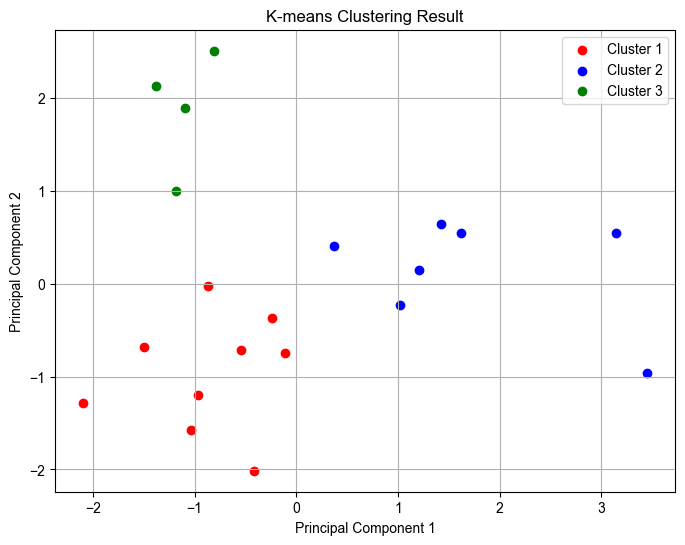

In [71]:
# PCA 降维到二维
pca = PCA(n_components=2)
points_2d = pca.fit_transform(points)

# 绘制聚类结果
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green']  # 定义每个聚类的颜色

for i in range(3):  # 假设有 3 个聚类
    cluster_points = points_2d[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[i], label=f'Cluster {i+1}')

plt.title('K-means Clustering Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

In [72]:
data['label'] = labels
data

,啤酒名,热量,钠含量,酒精,价格,label
0,Budweiser,144,19,4.7,0.43,0
1,Schlitz,181,19,4.9,0.43,0
2,Ionenbrau,157,15,4.9,0.48,0
3,Kronensourc,170,7,5.2,0.73,2
4,Heineken,152,11,5.0,0.77,2
5,Milnaukee,145,23,4.6,0.26,0
6,Aucsberger,175,24,5.5,0.40,0
7,Strchsbohemi,149,27,4.7,0.42,0
8,Miller-lite,99,10,4.3,0.43,1
9,Sudeiser,113,6,3.7,0.44,1


In [ ]:
#https://www.icourse163.org/learn/XMU-1206305809?tid=1454348451#/learn/content?type=detail&id=1227083128&cid=1242235149

In [83]:
# 1. 使用 Pandas 读取数据
data = pd.read_table('E:/大数据金融/Chap8/Chap8/pots.txt',delimiter=' ')
points = data.values  # 转换为 NumPy 数组

In [84]:
data

,Al2O3,Fe2O3,MgO,CaO,Na2O,K2O,TiO2,MnO,BaO,kiln
0,18.8,9.52,2.00,0.79,0.40,3.20,1.01,0.077,0.015,1
1,16.9,7.33,1.65,0.84,0.40,3.05,0.99,0.067,0.018,1
2,18.2,7.64,1.82,0.77,0.40,3.07,0.98,0.087,0.014,1
3,16.9,7.29,1.56,0.76,0.40,3.05,1.00,0.063,0.019,1
4,17.8,7.24,1.83,0.92,0.43,3.12,0.93,0.061,0.019,1
5,18.8,7.45,2.06,0.87,0.25,3.26,0.98,0.072,0.017,1
6,16.5,7.05,1.81,1.73,0.33,3.20,0.95,0.066,0.019,1
7,18.0,7.42,2.06,1.00,0.28,3.37,0.96,0.072,0.017,1
8,15.8,7.15,1.62,0.71,0.38,3.25,0.93,0.062,0.017,1
9,14.6,6.87,1.67,0.76,0.33,3.06,0.91,0.055,0.012,1


In [85]:
# 使用 StandardScaler 进行标准化
scaler = StandardScaler()
points = scaler.fit_transform(points)

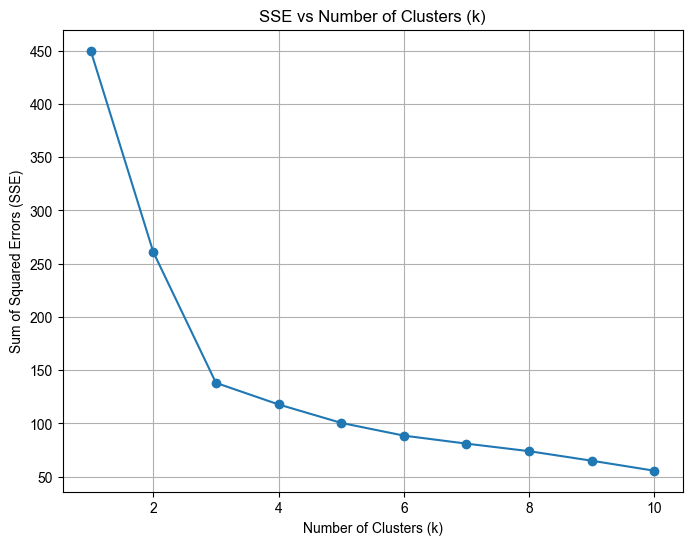

In [86]:
# 2. 碎石图：计算不同 k 的组内误差 (SSE)
sse = []
k_range = range(1, 11)  # 测试 k = 1 到 10
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(points)
    sse.append(kmeans.inertia_)  # SSE: 组内误差

    

# 绘制碎石图
plt.figure(figsize=(8, 6))
plt.plot(k_range, sse, marker='o')
plt.title('SSE vs Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.grid(True)
plt.show()

In [87]:
# 3. 选择 k 聚类 (假设选择 k=3)
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
labels = kmeans.fit_predict(points)

# 输出聚类结果
print("聚类标签:", labels)

聚类标签: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0
 0 0 0 0 0 0 0 0]


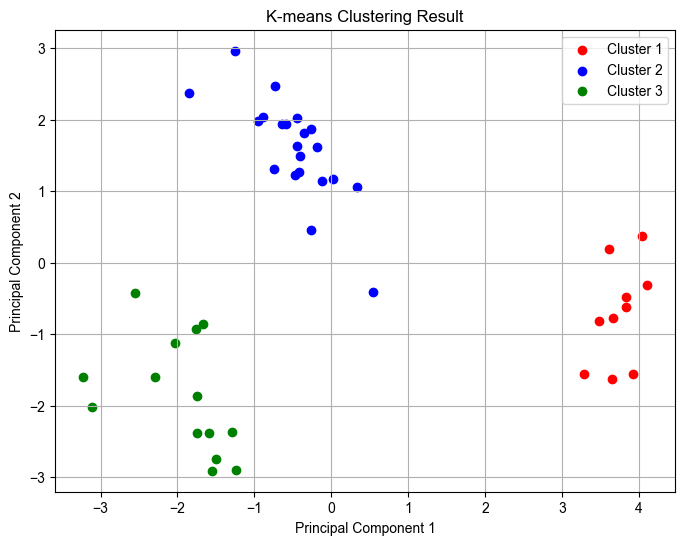

In [88]:
# PCA 降维到二维
pca = PCA(n_components=2)
points_2d = pca.fit_transform(points)

# 绘制聚类结果
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green']  # 定义每个聚类的颜色

for i in range(3):  # 假设有 3 个聚类
    cluster_points = points_2d[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[i], label=f'Cluster {i+1}')

plt.title('K-means Clustering Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

In [89]:
data['label'] = labels
data

,Al2O3,Fe2O3,MgO,CaO,Na2O,K2O,TiO2,MnO,BaO,kiln,label
0,18.8,9.52,2.00,0.79,0.40,3.20,1.01,0.077,0.015,1,1
1,16.9,7.33,1.65,0.84,0.40,3.05,0.99,0.067,0.018,1,1
2,18.2,7.64,1.82,0.77,0.40,3.07,0.98,0.087,0.014,1,1
3,16.9,7.29,1.56,0.76,0.40,3.05,1.00,0.063,0.019,1,1
4,17.8,7.24,1.83,0.92,0.43,3.12,0.93,0.061,0.019,1,1
5,18.8,7.45,2.06,0.87,0.25,3.26,0.98,0.072,0.017,1,1
6,16.5,7.05,1.81,1.73,0.33,3.20,0.95,0.066,0.019,1,1
7,18.0,7.42,2.06,1.00,0.28,3.37,0.96,0.072,0.017,1,1
8,15.8,7.15,1.62,0.71,0.38,3.25,0.93,0.062,0.017,1,1
9,14.6,6.87,1.67,0.76,0.33,3.06,0.91,0.055,0.012,1,1


In [92]:
data.groupby('label').count()

,Al2O3,Fe2O3,MgO,CaO,Na2O,K2O,TiO2,MnO,BaO,kiln
label,,,,,,,,,,
0,10,10,10,10,10,10,10,10,10,10
1,21,21,21,21,21,21,21,21,21,21
2,14,14,14,14,14,14,14,14,14,14


# 4

#https://github.com/fengdu78/WZU-machine-learning-course/blob/main/code/13-%E8%81%9A%E7%B1%BB/ML-lesson13-Clustering.ipynb

In [6]:
# 1. 使用 Pandas 读取数据
data = pd.read_csv('E:/大数据金融/ex7data2.csv')
points = data.values  # 转换为 NumPy 数组

In [7]:
data

,X1,X2
0,1.842080,4.607572
1,5.658583,4.799964
2,6.352579,3.290854
3,2.904017,4.612204
4,3.231979,4.939894
...,...,...
295,7.302787,3.380160
296,6.991984,2.987067
297,4.825534,2.779617
298,6.117681,2.854757


In [8]:
# 使用 StandardScaler 进行标准化
scaler = StandardScaler()
points = scaler.fit_transform(points)

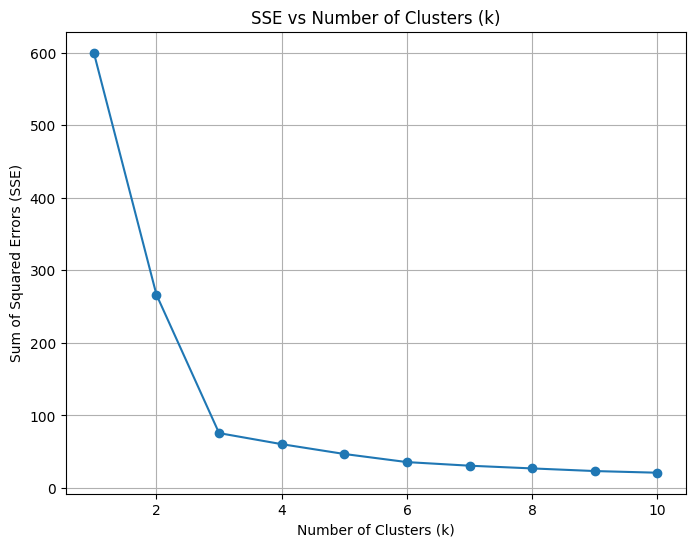

In [9]:
# 2. 碎石图：计算不同 k 的组内误差 (SSE)
sse = []
k_range = range(1, 11)  # 测试 k = 1 到 10
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(points)
    sse.append(kmeans.inertia_)  # SSE: 组内误差

    

# 绘制碎石图
plt.figure(figsize=(8, 6))
plt.plot(k_range, sse, marker='o')
plt.title('SSE vs Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.grid(True)
plt.show()

In [10]:
# 3. 选择 k 聚类 (假设选择 k=3)
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
labels = kmeans.fit_predict(points)

# 输出聚类结果
print("聚类标签:", labels)

聚类标签: [1 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 1]


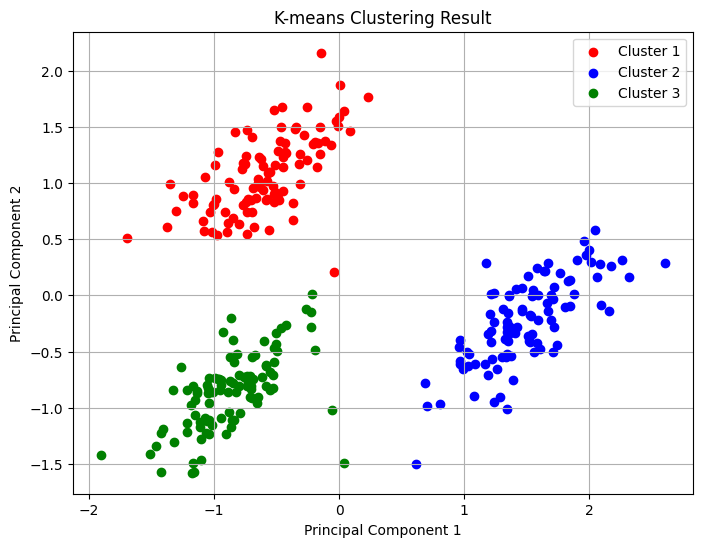

In [11]:
# PCA 降维到二维
pca = PCA(n_components=2)
points_2d = pca.fit_transform(points)

# 绘制聚类结果
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green']  # 定义每个聚类的颜色

for i in range(3):  # 假设有 3 个聚类
    cluster_points = points_2d[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[i], label=f'Cluster {i+1}')

plt.title('K-means Clustering Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
data['label'] = labels
data

,X1,X2,label
0,1.842080,4.607572,1
1,5.658583,4.799964,2
2,6.352579,3.290854,2
3,2.904017,4.612204,1
4,3.231979,4.939894,1
...,...,...,...
295,7.302787,3.380160,2
296,6.991984,2.987067,2
297,4.825534,2.779617,2
298,6.117681,2.854757,2


# 5

https://www.icourse163.org/learn/NJU-1449346162?tid=1473138456#/learn/content?type=detail&id=1259895455&cid=1295609090&contentid=480000001290611

In [17]:
# 1. 使用 Pandas 读取数据
data = pd.read_csv('E:/大数据金融/Chp7Data/tmdb_5000_movies.csv')
data=data[['budget','popularity', 'revenue']]
points = data.values  # 转换为 NumPy 数组

In [18]:
data

,budget,popularity,revenue
0,237000000,150.437577,2787965087
1,300000000,139.082615,961000000
2,245000000,107.376788,880674609
3,250000000,112.312950,1084939099
4,260000000,43.926995,284139100
...,...,...,...
4798,220000,14.269792,2040920
4799,9000,0.642552,0
4800,0,1.444476,0
4801,0,0.857008,0


In [19]:
# 使用 StandardScaler 进行标准化
scaler = StandardScaler()
points = scaler.fit_transform(points)

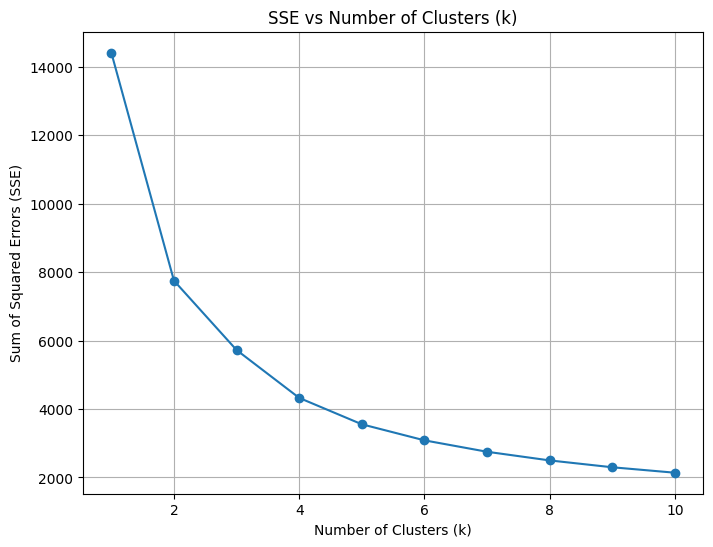

In [20]:
# 2. 碎石图：计算不同 k 的组内误差 (SSE)
sse = []
k_range = range(1, 11)  # 测试 k = 1 到 10
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(points)
    sse.append(kmeans.inertia_)  # SSE: 组内误差

    

# 绘制碎石图
plt.figure(figsize=(8, 6))
plt.plot(k_range, sse, marker='o')
plt.title('SSE vs Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.grid(True)
plt.show()

In [22]:
# 3. 选择 k 聚类 (假设选择 k=3)
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
labels = kmeans.fit_predict(points)

# 输出聚类结果
print("聚类标签:", labels)

聚类标签: [2 2 2 ... 1 1 1]


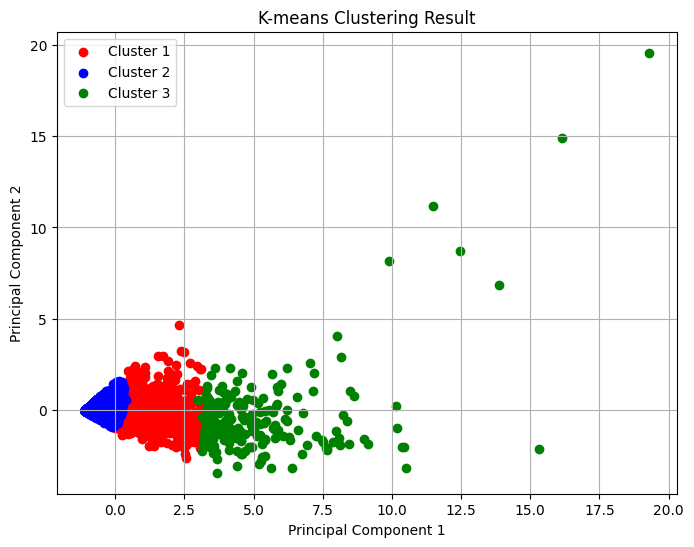

In [23]:
# PCA 降维到二维
pca = PCA(n_components=2)
points_2d = pca.fit_transform(points)

# 绘制聚类结果
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green']  # 定义每个聚类的颜色

for i in range(3):  # 假设有 3 个聚类
    cluster_points = points_2d[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[i], label=f'Cluster {i+1}')

plt.title('K-means Clustering Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
data['label'] = labels
data

,budget,popularity,revenue,label
0,237000000,150.437577,2787965087,2
1,300000000,139.082615,961000000,2
2,245000000,107.376788,880674609,2
3,250000000,112.312950,1084939099,2
4,260000000,43.926995,284139100,2
...,...,...,...,...
4798,220000,14.269792,2040920,1
4799,9000,0.642552,0,1
4800,0,1.444476,0,1
4801,0,0.857008,0,1
